In [1]:
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data_util
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
CUDA = torch.cuda.is_available()
print(f"CUDA available: {CUDA}")
device = torch.device('cuda:0' if CUDA else 'cpu')

CUDA available: True


In [3]:
elec = pd.read_csv('elec_merge.csv')
nelec = pd.read_csv('n_elec_merge.csv')
dhw = pd.read_csv('dhw_merge.csv')

In [4]:
elec = elec.drop(['YEAR'], axis=1)
nelec = nelec.drop(['YEAR'], axis=1)
dhw = dhw.drop(['YEAR'], axis=1)

In [5]:
# =============================================================
# 3. 전처리 - 1스텝 shift (다음 시간 예측)
# =============================================================
def make_input_target(df, target_col, new_col_name):
    input_df  = df.iloc[:-1].reset_index(drop=True)
    target_df = df[[target_col]].iloc[1:].reset_index(drop=True)
    target_df.columns = [new_col_name]
    return pd.concat([input_df, target_df], axis=1)

nelec = make_input_target(nelec, 'n_elec', 'nelec')
elec  = make_input_target(elec,  'ELEC',   'elec')
dhw   = make_input_target(dhw,   'DHW',    'dhw')

In [6]:
# =============================================================
# 4. 스케일링 - X+Y 통합 스케일링 (역변환용 스케일러 보관)
# =============================================================
scaler_nelec = MinMaxScaler()
scaler_elec  = MinMaxScaler()
scaler_dhw   = MinMaxScaler()

nelec = pd.DataFrame(scaler_nelec.fit_transform(nelec), columns=nelec.columns)
elec  = pd.DataFrame(scaler_elec.fit_transform(elec),   columns=elec.columns)
dhw   = pd.DataFrame(scaler_dhw.fit_transform(dhw),     columns=dhw.columns)

In [7]:
# =============================================================
# 5. Train / Test 분리
# =============================================================
def split_train_test(df, ratio=0.7):
    n = int(len(df) * ratio)
    return df.iloc[:n], df.iloc[n:].reset_index(drop=True)

nelec_train, nelec_test = split_train_test(nelec)
elec_train,  elec_test  = split_train_test(elec)
dhw_train,   dhw_test   = split_train_test(dhw)

def split_xy(df, target_col):
    return df.drop([target_col], axis=1), df[[target_col]]

nelec_trainx, nelec_trainy = split_xy(nelec_train, 'nelec')
nelec_testx,  nelec_testy  = split_xy(nelec_test,  'nelec')
elec_trainx,  elec_trainy  = split_xy(elec_train,  'elec')
elec_testx,   elec_testy   = split_xy(elec_test,   'elec')
dhw_trainx,   dhw_trainy   = split_xy(dhw_train,   'dhw')
dhw_testx,    dhw_testy    = split_xy(dhw_test,    'dhw')

In [8]:
# =============================================================
# 6. 시퀀스 데이터셋 생성
# [수정] range: len-seqLength → len-seqLength+1 (마지막 샘플 복구)
# ty: seqLength-1 → seqLength (명확한 다음 1시간 예측)
# =============================================================
SEQ_LEN = 7

def buildDataSet(input, target, seqLength):
    xdata, ydata = [], []
    for i in range(len(input) - seqLength):          # [수정] +1 제거 (ty가 seqLength라 범위 동일)
        tx = input.iloc[i:i + seqLength]
        ty = target.iloc[i + seqLength - 1]          # shift로 인해 실질적으로 다음 시간
        xdata.append(tx)
        ydata.append(ty)
    return np.array(xdata), np.array(ydata)

nelec_trainx, nelec_trainy = buildDataSet(nelec_trainx, nelec_trainy, SEQ_LEN)
nelec_testx,  nelec_testy  = buildDataSet(nelec_testx,  nelec_testy,  SEQ_LEN)
elec_trainx,  elec_trainy  = buildDataSet(elec_trainx,  elec_trainy,  SEQ_LEN)
elec_testx,   elec_testy   = buildDataSet(elec_testx,   elec_testy,   SEQ_LEN)
dhw_trainx,   dhw_trainy   = buildDataSet(dhw_trainx,   dhw_trainy,   SEQ_LEN)
dhw_testx,    dhw_testy    = buildDataSet(dhw_testx,    dhw_testy,    SEQ_LEN)

print(f"nelec train: X={nelec_trainx.shape}, Y={nelec_trainy.shape}")
print(f"dhw   train: X={dhw_trainx.shape},   Y={dhw_trainy.shape}")

nelec train: X=(20409, 7, 12), Y=(20409, 1)
dhw   train: X=(20409, 7, 12),   Y=(20409, 1)


In [9]:
# =============================================================
# 7. DataLoader 생성
# =============================================================
def make_loader(x, y, batch_size=1024, shuffle=False):
    dataset = TensorDataset(torch.FloatTensor(x), torch.FloatTensor(y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=True)

NELEC_train = make_loader(nelec_trainx, nelec_trainy)
NELEC_test  = make_loader(nelec_testx,  nelec_testy)
ELEC_train  = make_loader(elec_trainx,  elec_trainy)
ELEC_test   = make_loader(elec_testx,   elec_testy)
DHW_train   = make_loader(dhw_trainx,   dhw_trainy)
DHW_test    = make_loader(dhw_testx,    dhw_testy)

# 모델 구조 선언

### GradientReversalLayer

In [10]:
# --- Gradient Reversal Layer ---
# [수정] alpha 인자 추가 → 학습 진행에 따라 gradient 강도 조절 가능
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.save_for_backward(torch.tensor(alpha))
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        alpha, = ctx.saved_tensors
        return (grad_output * -alpha.item()), None  # [수정] 고정 -1 → -alpha

class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, alpha=1.0):
        return GradientReversalFunction.apply(x, alpha)

### LSTM for Feature Extraction

In [11]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(x)

In [12]:
# [수정] lstm3에 bn2 재사용 → bn3_lstm 별도 선언
class lstm(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(12, 64, batch_first=True)
        self.bn1   = nn.BatchNorm1d(SEQ_LEN)

        self.lstm2 = nn.LSTM(64, 64, batch_first=True)
        self.bn2   = nn.BatchNorm1d(SEQ_LEN)

        self.lstm3    = nn.LSTM(64, 64, batch_first=True)
        self.bn3_lstm = nn.BatchNorm1d(SEQ_LEN)     # [수정] 별도 선언

        self.fc   = nn.Linear(64, 64, bias=False)
        self.bn_fc = nn.BatchNorm1d(SEQ_LEN)         # [수정] 명확한 이름
        self.fc2  = nn.Linear(64, 100, bias=False)

        self.dropout = nn.Dropout(0.5)
        self.swish   = Swish()
        self.tanh    = nn.Tanh()

    def forward(self, x):
        x, (h, c) = self.lstm1(x)
        x = self.bn1(x)
        x = self.tanh(x)

        x, (h, c) = self.lstm2(x, (h, c))
        x = self.bn2(x)
        x = self.tanh(x)

        x, _ = self.lstm3(x, (h, c))
        x = self.bn3_lstm(x)                         # [수정] bn2 → bn3_lstm
        x = self.tanh(x)

        x = self.fc(x)
        x = self.bn_fc(x)                            # [수정] bn3 → bn_fc
        x = self.fc2(x[:, -1, :])
        x = self.dropout(x)
        x = self.swish(x)
        return x

In [13]:
# [수정] 출력 swish 제거 → linear (회귀 출력)
class domain_regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1   = nn.Linear(100, 100)
        self.fc2   = nn.Linear(100, 100)
        self.fc3   = nn.Linear(100, 100)
        self.fc4   = nn.Linear(100, 1)
        self.swish = Swish()

    def forward(self, x):
        x = self.swish(self.fc1(x))
        x = self.swish(self.fc2(x))
        x = self.swish(self.fc3(x))
        x = self.fc4(x)                              # [수정] swish 제거 → linear
        return x

### Domain Classification

In [14]:
# [수정] sigmoid 제거 → BCEWithLogitsLoss가 내부 처리
# [수정] alpha를 GRL에 전달
class domain_classfication(nn.Module):
    def __init__(self):
        super().__init__()
        self.grl   = GradientReversalLayer()
        self.fc1   = nn.Linear(100, 100)
        self.fc2   = nn.Linear(100, 100)
        self.fc3   = nn.Linear(100, 100)
        self.fc4   = nn.Linear(100, 1)
        self.swish = Swish()

    def forward(self, x, alpha=1.0):
        x = self.grl(x, alpha)                       # [수정] alpha 전달
        x = self.swish(self.fc1(x))
        x = self.swish(self.fc2(x))
        x = self.swish(self.fc3(x))
        x = self.fc4(x)                              # [수정] sigmoid 제거
        return x

### Set the DANN

In [15]:
# --- DANN ---
class dann(nn.Module):
    def __init__(self, lstm_model):
        super().__init__()
        self.lstm           = lstm_model
        self.regression     = domain_regression()
        self.classification = domain_classfication()

    def forward(self, x, alpha=1.0):                 # [수정] alpha 인자 추가
        feature    = self.lstm(x)
        reg_output = self.regression(feature)
        cla_output = self.classification(feature, alpha)
        return reg_output, cla_output

### Loss 선언

In [ ]:
class dann_loss(nn.Module):
    def __init__(self):
        super().__init__()
        self.reg = nn.L1Loss()
        self.cla = nn.BCEWithLogitsLoss()            # sigmoid 없이 logit 직접 받음

    def forward(self, result, reg_real, domain_num):
        reg_output, cla_output = result
        batch_size = reg_output.shape[0]
        cla_target = torch.FloatTensor([domain_num] * batch_size).unsqueeze(1).to(device)

        reg_loss = self.reg(reg_output, reg_real)
        cla_loss = self.cla(cla_output, cla_target)
        loss     = reg_loss + cla_loss

        return loss, reg_loss, cla_loss

In [17]:
# =============================================================
# 9. 모델 초기화
# =============================================================
my_lstm  = lstm().to(device)
model    = dann(my_lstm).to(device)
loss_fn  = dann_loss().to(device)

# 훈련

In [19]:
# =============================================================
# 10. 학습 루프
# [수정] alpha 점진적 증가 (DANN 논문 방식: 0 → 1)
# [수정] 학습 루프 주석 해제 및 정리
# =============================================================
from torch.optim.lr_scheduler import LinearLR

epochs  = 200
patience = 100
best_loss            = float('inf')
best_model_state     = None
counter              = 0

optimizer = torch.optim.Adamax(model.parameters(), lr=1e-3)
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.0,
                     total_iters=epochs * len(NELEC_train))

model.train()

for epoch in range(1, epochs + 1):
    # [수정] alpha 점진적 증가: 0 → 1
    p     = epoch / (epochs * 3)
    alpha = 2 / (1 + np.exp(-10 * p)) - 1

    total_loss    = 0.0
    reg_loss_total = 0.0
    cla_loss_total = 0.0

    for source_data, target_data in zip(NELEC_train, DHW_train):
        source_x, source_y = source_data[0].to(device), source_data[1].to(device)
        target_x, target_y = target_data[0].to(device), target_data[1].to(device)

        source_result = model(source_x, alpha=alpha)
        target_result = model(target_x, alpha=alpha)

        source_loss, source_reg, source_cla = loss_fn(source_result, source_y, 1)
        target_loss, target_reg, target_cla = loss_fn(target_result, target_y, 0)

        loss     = source_loss + target_loss
        reg_loss = source_reg  + target_reg
        cla_loss = source_cla  + target_cla

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss     += loss.item()
        reg_loss_total += reg_loss.item()
        cla_loss_total += cla_loss.item()

    avg_total = total_loss     / len(NELEC_train)
    avg_reg   = reg_loss_total / len(NELEC_train)
    avg_cla   = cla_loss_total / len(NELEC_train)

    print(f"Epoch {epoch:3d} | alpha={alpha:.3f} | Total={avg_total:.4f} | Reg={avg_reg:.4f} | Cla={avg_cla:.4f}")

    if avg_reg < best_loss:
        best_loss        = avg_reg
        best_model_state = model.state_dict()
        counter          = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

if best_model_state is not None:
    torch.save(best_model_state, '0810hoxyhoxy7.pth')
    print("Best model saved.")

Epoch   1 | alpha=0.008 | Total=1.8917 | Reg=0.5072 | Cla=1.3845
Epoch   2 | alpha=0.017 | Total=1.6950 | Reg=0.3246 | Cla=1.3704
Epoch   3 | alpha=0.025 | Total=1.5451 | Reg=0.2296 | Cla=1.3155
Epoch   4 | alpha=0.033 | Total=1.4257 | Reg=0.1810 | Cla=1.2448
Epoch   5 | alpha=0.042 | Total=1.3204 | Reg=0.1690 | Cla=1.1514
Epoch   6 | alpha=0.050 | Total=1.3049 | Reg=0.1545 | Cla=1.1504
Epoch   7 | alpha=0.058 | Total=1.3310 | Reg=0.1598 | Cla=1.1712
Epoch   8 | alpha=0.067 | Total=1.2676 | Reg=0.1679 | Cla=1.0997
Epoch   9 | alpha=0.075 | Total=1.2524 | Reg=0.1426 | Cla=1.1098
Epoch  10 | alpha=0.083 | Total=1.2130 | Reg=0.1241 | Cla=1.0889
Epoch  11 | alpha=0.091 | Total=1.1987 | Reg=0.1112 | Cla=1.0875
Epoch  12 | alpha=0.100 | Total=1.2490 | Reg=0.1098 | Cla=1.1391
Epoch  13 | alpha=0.108 | Total=1.3196 | Reg=0.1108 | Cla=1.2088
Epoch  14 | alpha=0.116 | Total=1.3097 | Reg=0.1129 | Cla=1.1969
Epoch  15 | alpha=0.124 | Total=1.2400 | Reg=0.1156 | Cla=1.1244
Epoch  16 | alpha=0.133 |

In [20]:
# =============================================================
# 11. 평가 함수
# =============================================================
def evaluate(model, source_loader, target_loader, device):
    model.eval()
    s_pred, s_real = [], []
    t_pred, t_real = [], []

    with torch.no_grad():
        for source_data, target_data in zip(source_loader, target_loader):
            source_x, source_y = source_data[0].to(device), source_data[1].to(device)
            target_x, target_y = target_data[0].to(device), target_data[1].to(device)

            # [수정] reg_output, cla_output 순서 올바르게 받음
            source_reg, _ = model(source_x)
            target_reg, _ = model(target_x)

            s_pred.extend(source_reg.cpu().numpy())
            t_pred.extend(target_reg.cpu().numpy())
            s_real.extend(source_y.cpu().numpy())
            t_real.extend(target_y.cpu().numpy())

    return np.array(s_pred), np.array(s_real), np.array(t_pred), np.array(t_real)

# train 데이터로 테스트


[Train 평가]
SOURCE R2  : 0.6629
TARGET R2  : 0.5822
SOURCE MAE : 0.0784
TARGET MAE : 0.1328


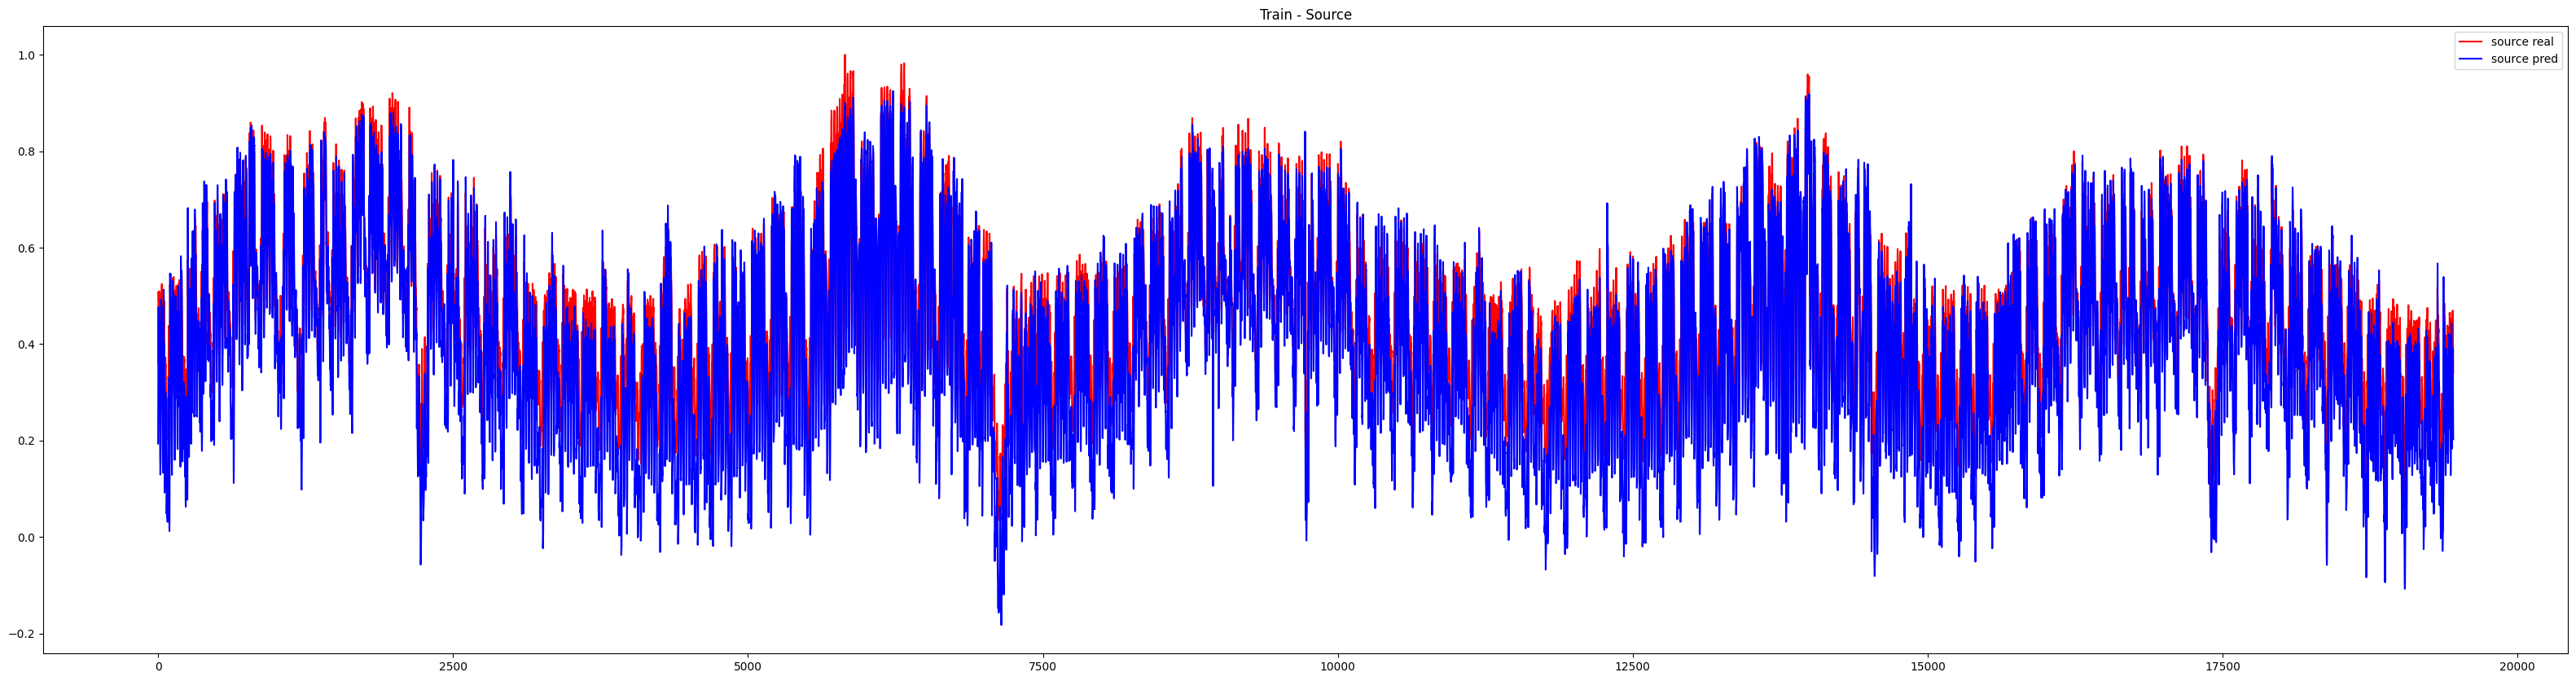

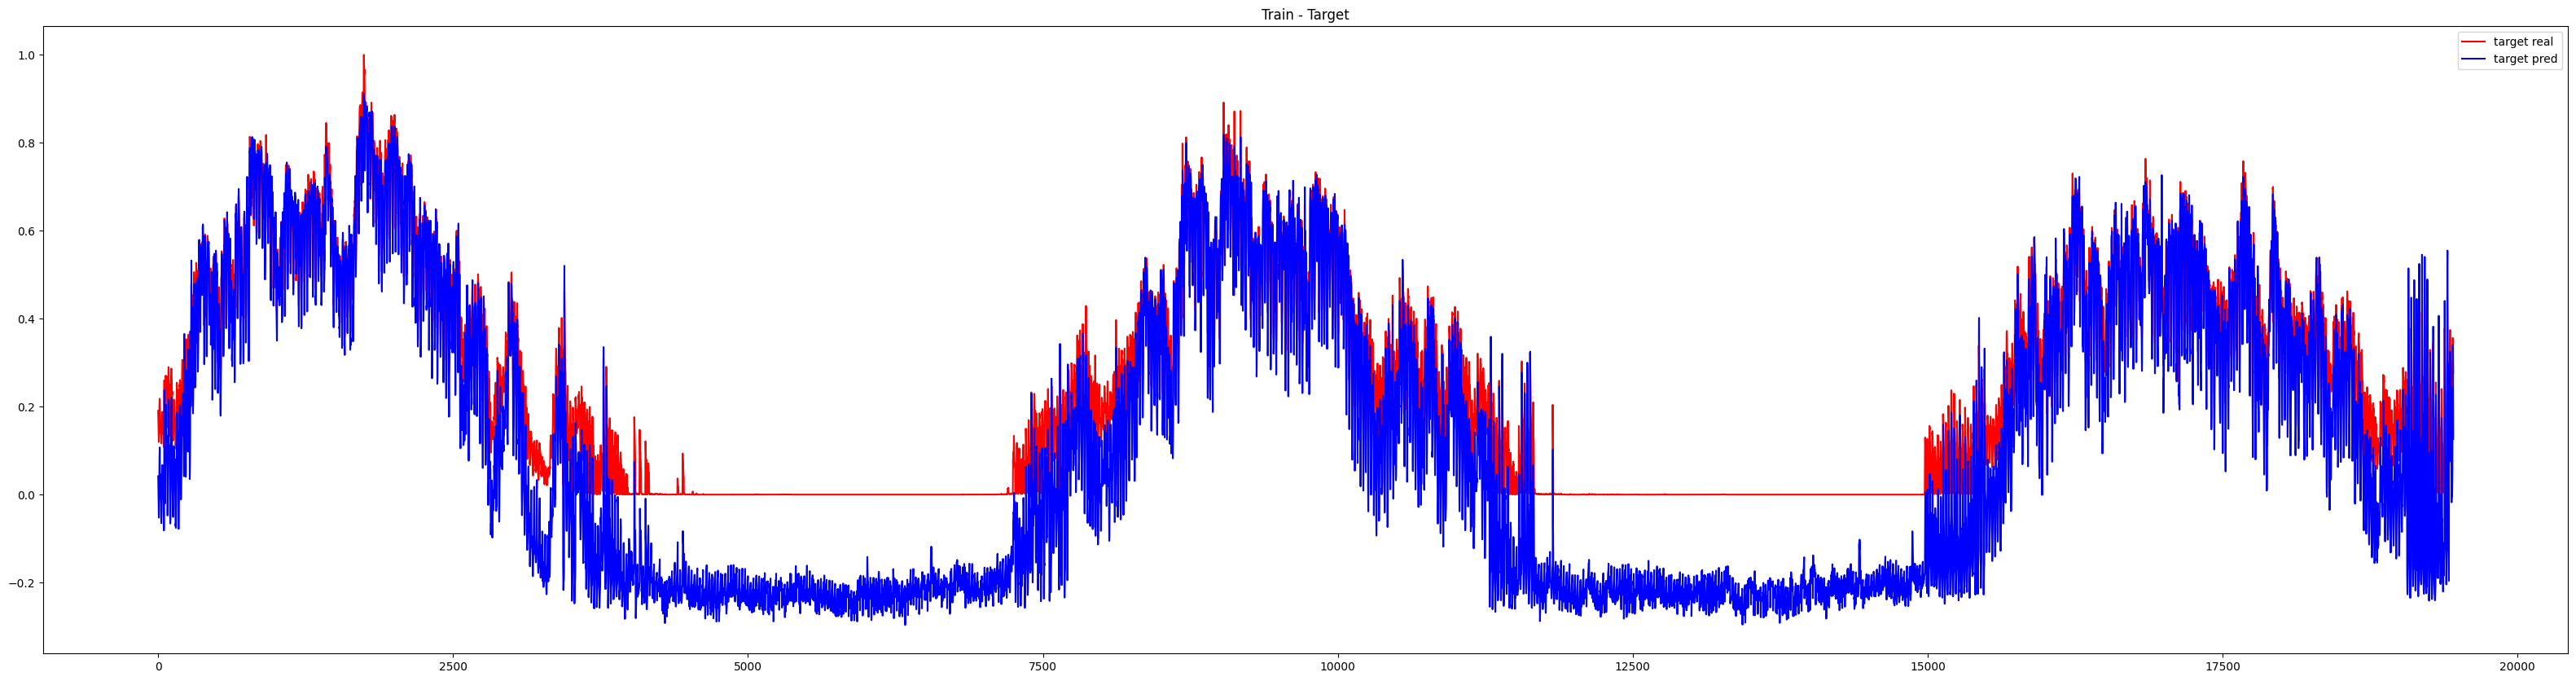

In [21]:
# =============================================================
# 12. Train 데이터 평가
# =============================================================
best_model = dann(lstm().to(device)).to(device)
best_model.load_state_dict(torch.load('0810hoxyhoxy7.pth'))

s_pred, s_real, t_pred, t_real = evaluate(best_model, NELEC_train, DHW_train, device)

print("\n[Train 평가]")
print(f"SOURCE R2  : {r2_score(s_real, s_pred):.4f}")
print(f"TARGET R2  : {r2_score(t_real, t_pred):.4f}")
print(f"SOURCE MAE : {mean_absolute_error(s_real, s_pred):.4f}")
print(f"TARGET MAE : {mean_absolute_error(t_real, t_pred):.4f}")

plt.figure(figsize=(40, 10))
plt.plot(s_real, color='red',  label='source real')
plt.plot(s_pred, color='blue', label='source pred')
plt.legend(); plt.title('Train - Source'); plt.show()

plt.figure(figsize=(40, 10))
plt.plot(t_real, color='red',  label='target real')
plt.plot(t_pred, color='blue', label='target pred')
plt.legend(); plt.title('Train - Target'); plt.show()

# test 데이터로 테스트


[Test 평가]
SOURCE R2  : 0.6311
TARGET R2  : 0.4932
SOURCE MAE : 0.0828
TARGET MAE : 0.1501


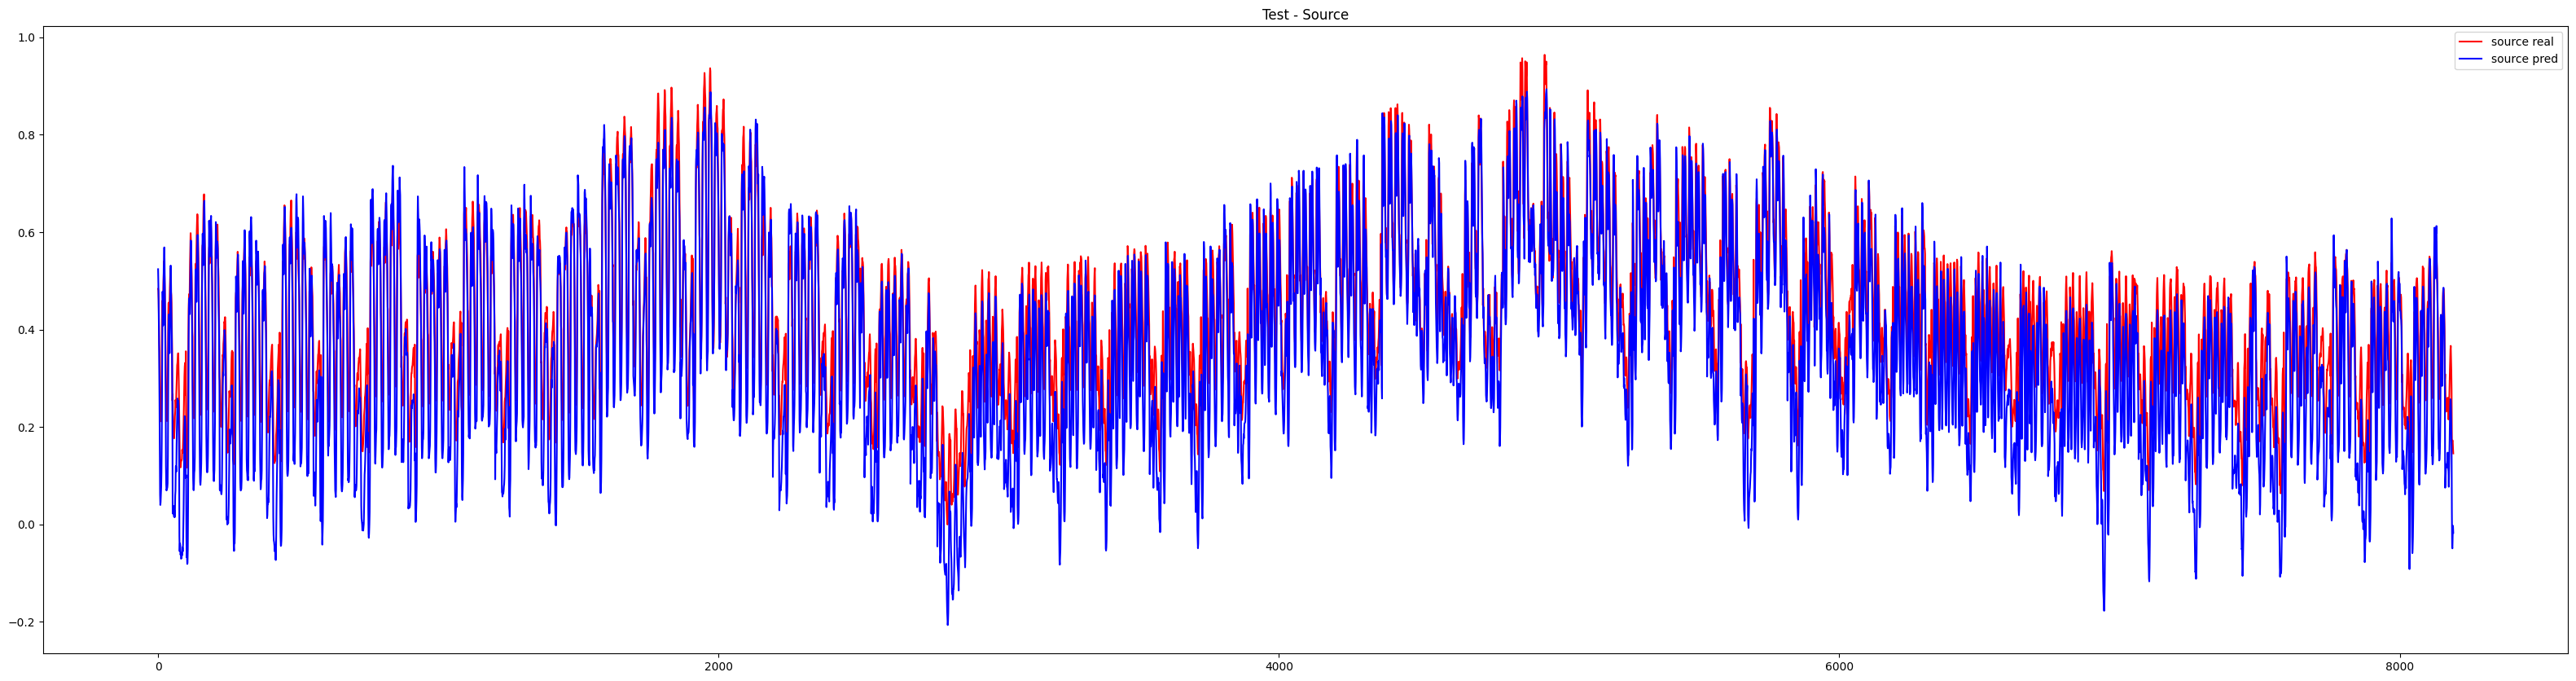

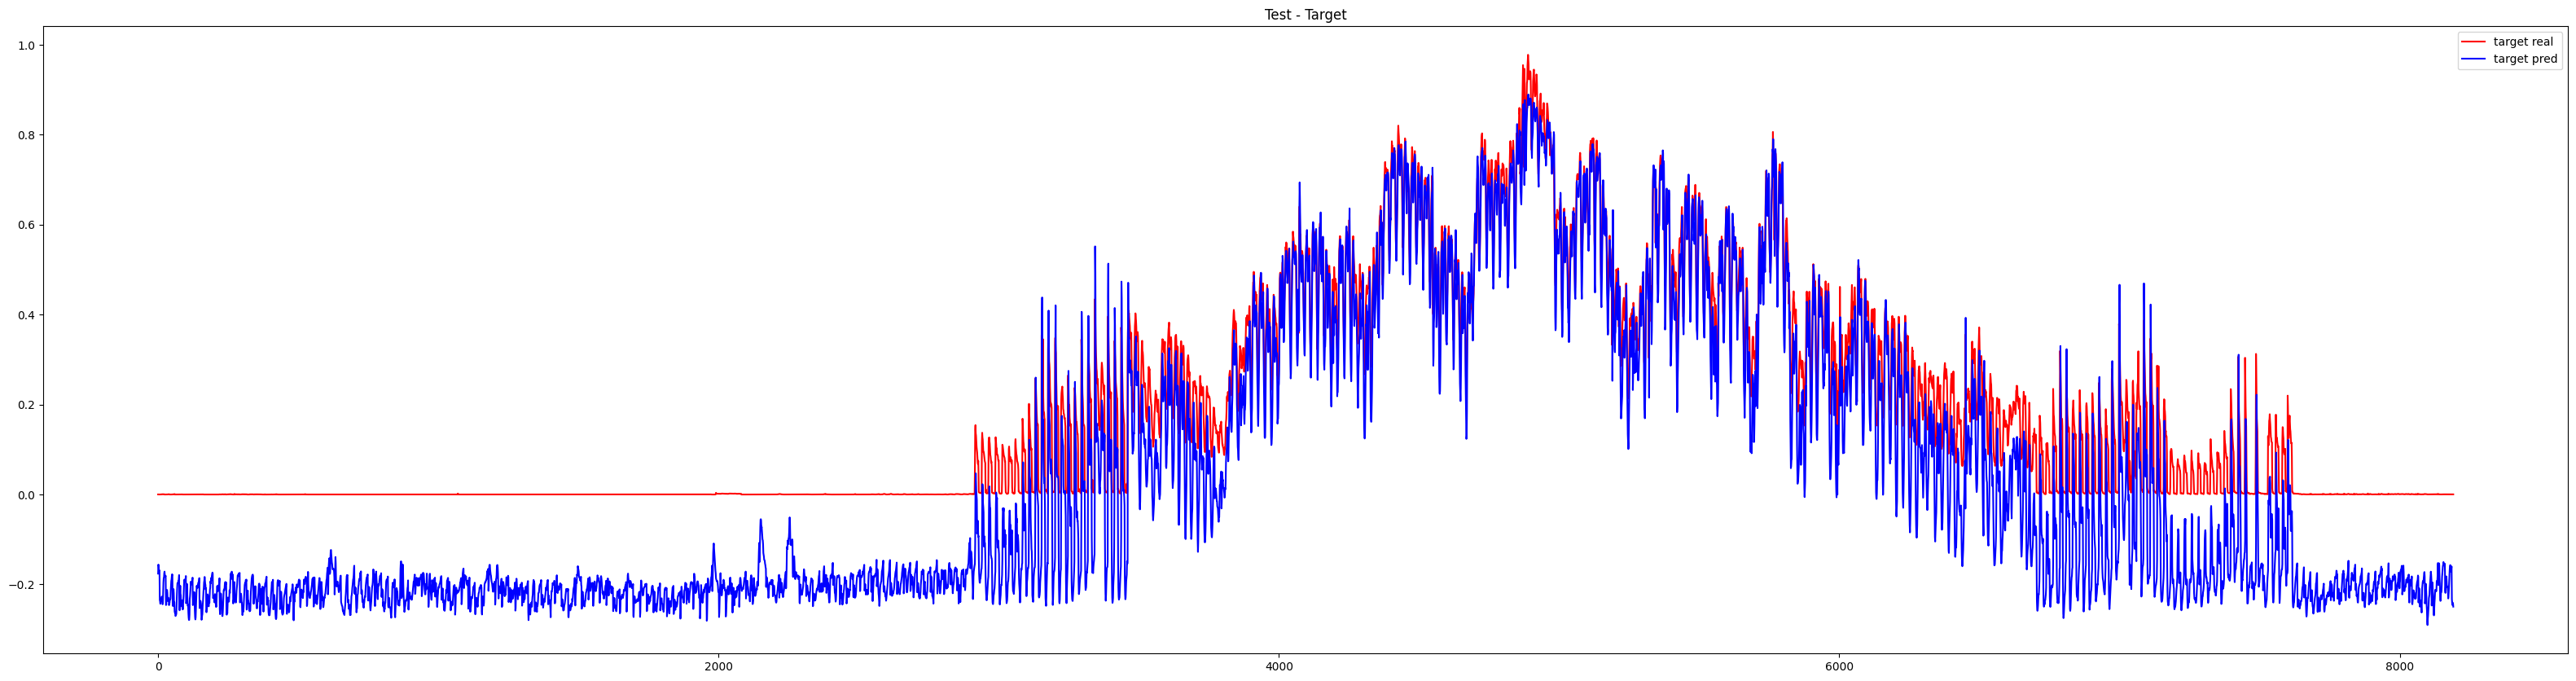

In [22]:
# =============================================================
# 13. Test 데이터 평가
# =============================================================
s_pred, s_real, t_pred, t_real = evaluate(best_model, NELEC_test, DHW_test, device)

print("\n[Test 평가]")
print(f"SOURCE R2  : {r2_score(s_real, s_pred):.4f}")
print(f"TARGET R2  : {r2_score(t_real, t_pred):.4f}")
print(f"SOURCE MAE : {mean_absolute_error(s_real, s_pred):.4f}")
print(f"TARGET MAE : {mean_absolute_error(t_real, t_pred):.4f}")

plt.figure(figsize=(40, 10))
plt.plot(s_real, color='red',  label='source real')
plt.plot(s_pred, color='blue', label='source pred')
plt.legend(); plt.title('Test - Source'); plt.show()

plt.figure(figsize=(40, 10))
plt.plot(t_real, color='red',  label='target real')
plt.plot(t_pred, color='blue', label='target pred')
plt.legend(); plt.title('Test - Target'); plt.show()

### Domain Embedding Space 시각화

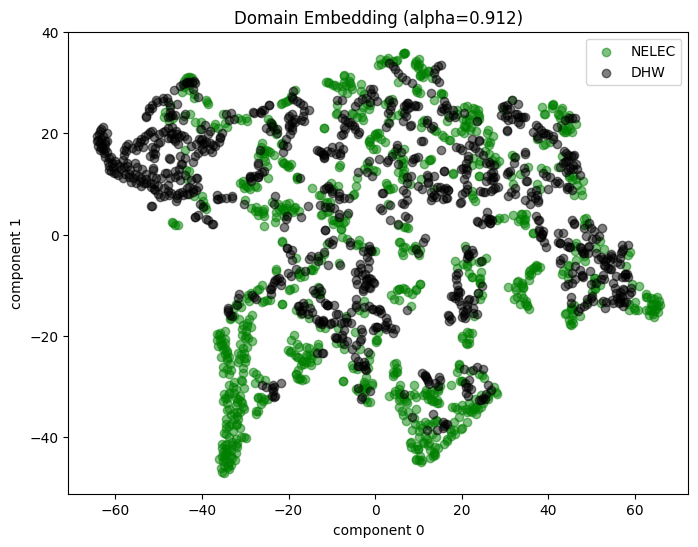

In [23]:
# =============================================================
# 14. t-SNE 도메인 임베딩 시각화
# [수정] tsne_df.loc → tsne_df.iloc (중복 인덱스 방지)
# =============================================================
from sklearn.manifold import TSNE

source_tsne_loader = DataLoader(
    TensorDataset(torch.FloatTensor(nelec_trainx), torch.FloatTensor(nelec_trainy)),
    batch_size=1000, shuffle=False
)
target_tsne_loader = DataLoader(
    TensorDataset(torch.FloatTensor(dhw_trainx), torch.FloatTensor(dhw_trainy)),
    batch_size=1000, shuffle=False
)

source_batch = next(iter(source_tsne_loader))
target_batch = next(iter(target_tsne_loader))

best_model.eval()
with torch.no_grad():
    source_vector = best_model.lstm(source_batch[0].to(device)).cpu().numpy()
    target_vector = best_model.lstm(target_batch[0].to(device)).cpu().numpy()

combined = np.concatenate([source_vector, target_vector])
tsne_np  = TSNE(n_components=2).fit_transform(pd.DataFrame(combined))
tsne_df  = pd.DataFrame(tsne_np, columns=['component 0', 'component 1'])

n_source = len(source_vector)
tsne_df_0 = tsne_df.iloc[:n_source]           # [수정] loc → iloc
tsne_df_1 = tsne_df.iloc[n_source:]           # [수정] loc → iloc, 중복 제거

plt.figure(figsize=(8, 6))
plt.scatter(tsne_df_0['component 0'], tsne_df_0['component 1'], color='green', label='NELEC', alpha=0.5)
plt.scatter(tsne_df_1['component 0'], tsne_df_1['component 1'], color='black', label='DHW',   alpha=0.5)
plt.title(f'Domain Embedding (alpha={alpha:.3f})')
plt.xlabel('component 0')
plt.ylabel('component 1')
plt.legend()
plt.show()